# 03: LIDC-IDRI Dataset Visualisation

This notebook explores the real CT data we train and evaluate on, with the aim of understanding:

- What the LIDC-IDRI dataset is and where it comes from
- The raw to processed preprocessing pipeline applied by LION
- What real CT slices look like
- The intensity distribution and normalisation convention
- How LION's dataloader serves images to the training loop
- The train/validation/test split used in our experiments

This exploration is directly relevant to the project as it helps understand how data is normalised, as well as what format it needs to be in at each point of the model pipeline.

### Note on data location

This notebook runs against the full LIDC-IDRI dataset on CSD3 (~1018 patients, ~125 GB), located at `~/rds/hpc-work/LIDC-IDRI`. The patient-level train/validation/test split is delegated to LION's built-in `LIDC_IDRI` dataloader, which yields 3300 / 401 / 389 slices respectively — these are the splits the training and evaluation notebooks (NB09, NB10) rely on.

## 1. Setup

In [29]:
# import all necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from skimage.transform import radon, iradon
from pathlib import Path
import os

# add error handling for pydicom import
try:
    import pydicom
    HAS_DICOM = True
except ImportError:
    HAS_DICOM = False
    print("pydicom not installed — raw DICOM cells will be skipped.")

# set consistent plotting style for all notebook cells
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "image.cmap": "gray",
    "image.interpolation": "nearest",
})

# create output directory for figures
output_dir = Path("../figures/03")
output_dir.mkdir(parents=True, exist_ok=True)

# set up and print paths to raw and processed data directories
NOTEBOOK_DIR  = Path.cwd()
DATA_ROOT     = Path.home() / "rds" / "hpc-work" / "LIDC-IDRI"
RAW_DIR       = DATA_ROOT / "raw" / "LIDC-IDRI" / "LIDC-IDRI"
PROCESSED_DIR = DATA_ROOT / "processed" / "LIDC-IDRI"

print(f"Data root      : {DATA_ROOT}")
print(f"Raw DICOM dir  : {RAW_DIR}")
print(f"Processed dir  : {PROCESSED_DIR}")

Data root      : /home/eaz21/rds/hpc-work/LIDC-IDRI
Raw DICOM dir  : /home/eaz21/rds/hpc-work/LIDC-IDRI/raw/LIDC-IDRI/LIDC-IDRI
Processed dir  : /home/eaz21/rds/hpc-work/LIDC-IDRI/processed/LIDC-IDRI


### A note on displaying CT images

Before visualising any images it is important to understand how the data is stored.

The processed `.npy` files contain raw int16 Hounsfield Unit (HU) values, not pre-normalised pixel values.

The full physical range of HU values in a CT scan has a very large span, and passing this directly to `imshow` with `vmin=0, vmax=1` clamps everything to white as almost all HU values are orders of magnitude larger than 1. To display images correctly, I applied a lung window to clip all images to [−1000, +400] HU, which is the clinically relevant range for a chest CT. The image is then rescaled to [0, 1] for consistency.

**This windowing is purely for display.** It is applied in every visualisation cell of this notebook so that anatomy is legible, but it does **not** correspond to the conversion used by the pipeline. The pipeline uses `from_HU_to_mu` (defined in `ct_tfpnp.datasets.lidc`), which converts HU to physical linear attenuation coefficients (µ, cm⁻¹). The CT operator and policy network operate on µ-valued images, not on lung-windowed ones. The two functions are kept entirely separate.

In [30]:
def apply_lung_window(arr, hu_min=-1000, hu_max=400):

    """Clip to HU range and normalise to [0, 1] for display only."""

    # clip to HU range
    clipped = np.clip(arr.astype(np.float32), hu_min, hu_max)

    # normalise to [0, 1]
    return (clipped - hu_min) / (hu_max - hu_min)

## 2. About the LIDC-IDRI Dataset

The **Lung Image Database Consortium and Image Database Resource Initiative (LIDC-IDRI)** is the standard benchmark dataset for CT reconstruction research, and is the dataset of choice for this project due to its already strong integration with LION.

Key facts:
- Contains chest CT scans of 1,018 patients
- Collected from 7 academic medical centres
- Publicly available via the Cancer Imaging Archive (TCIA)
- Used in LION's default dataloader

#### Why chest CT? 

Lung CT has high contrast between soft tissue, air-filled lungs, and bone, which makes it a challenging and representative benchmark for reconstruction algorithms.


## 3. Dataset Directory Structure

It is helpful to understand the structure of the dataset before working with any of the images. This is because the processed directory contains two distinct types of `.npy` file, `slice_*.npy` (CT images) and `mask_*.npy` (nodule annotation masks), which must be handled separately. Accidentally including mask files when loading images will produce incorrect statistics and blank visualisations, so thoroughly exploring the layout in advance helps prevent this from happening.

The raw directory contains the original DICOM files organised by patient and scan session. The processed directory contains the output of LION's preprocessing script (`pre_process_lidc_idri.py`), with one subdirectory per patient.

In [ ]:
# visualise directory structure
def print_tree(path, max_depth=3, max_files=3, max_dirs=3, _prefix="", _depth=0):

    # add error handling for non-existent paths and max depth
    if _depth > max_depth or not Path(path).exists():
        return
    
    # list and sort items, then separate into dirs and files
    items  = sorted(Path(path).iterdir())
    dirs   = [p for p in items if p.is_dir()]
    files  = [p for p in items if p.is_file()]

    # print directories first (limited by max_dirs), then files (limited by max_files)
    for d in dirs[:max_dirs]:
        print(f"{_prefix}📁 {d.name}/")
        print_tree(d, max_depth, max_files, max_dirs, _prefix + "   ", _depth + 1)

    if len(dirs) > max_dirs:
        print(f"{_prefix}   ... and {len(dirs) - max_dirs} more directories")

    for f in files[:max_files]:
        print(f"{_prefix}📄 {f.name}  ({f.stat().st_size // 1024} KB)")
        
    if len(files) > max_files:
        print(f"{_prefix}   ... and {len(files) - max_files} more files")

# print directory trees for raw and processed data
print("=== Raw DICOM structure ===")
print_tree(RAW_DIR, max_depth=3, max_files=2, max_dirs=3)
print()
print("=== Processed structure ===")
print_tree(PROCESSED_DIR, max_depth=3, max_files=3, max_dirs=3)

=== Raw DICOM structure ===
📁 LIDC-IDRI-0001/
   📁 01-01-2000-30178/
      📁 3000566.000000-03192/
         📄 069.xml  (302 KB)
         📄 1-001.dcm  (514 KB)
            ... and 133 more files
   📁 01-01-2000-35511/
      📁 3000923.000000-62357/
         📄 068.xml  (3 KB)
         📄 1-1.dcm  (7987 KB)
            ... and 2 more files
📁 LIDC-IDRI-0002/
   📁 01-01-2000-26851/
      📁 3000972.000000-22902/
         📄 070.xml  (3 KB)
         📄 1-1.dcm  (6748 KB)
            ... and 1 more files
   📁 01-01-2000-98329/
      📁 3000522.000000-04919/
         📄 071.xml  (324 KB)
         📄 1-001.dcm  (514 KB)
            ... and 261 more files
📁 LIDC-IDRI-0003/
   📁 01-01-2000-59141/
      📁 3000978.000000-59882/
         📄 073.xml  (8 KB)
         📄 1-1.dcm  (7987 KB)
            ... and 5 more files
   📁 01-01-2000-94866/
      📁 3000611.000000-03264/
         📄 072.xml  (398 KB)
         📄 1-001.dcm  (514 KB)
            ... and 140 more files
   ... and 1007 more directories
📄 LICENSE  (

## 4. The Raw Data: DICOM Files

The raw data is stored in **DICOM** format (`.dcm`), which is the medical imaging standard.

Each `.dcm` file corresponds to one 2D CT slice, and a patient folder typically contains 100–500 slices stacked along the z-axis.

DICOM files contain:
- The pixel array (raw Hounsfield Units)
- Rich metadata: patient ID, scanner model, slice thickness, pixel spacing, etc.

`pydicom` is used to read them.

In [ ]:
# add error handling for missing pydicom
if not HAS_DICOM:
    print("Skipping — pydicom not installed.")

else:
    # Find first available DICOM file in the raw directory
    dcm_files = sorted(RAW_DIR.glob("**/*.dcm"))

    # print warning if no DICOM files found
    if not dcm_files:
        print(f"No .dcm files found under {RAW_DIR}")

    # print summary
    else:
        print(f"Found {len(dcm_files)} DICOM files across {len(list(RAW_DIR.glob('LIDC-IDRI-*')))} patients")
        
        # Load one example slice
        dcm = pydicom.dcmread(dcm_files[0])
        print(f"\nExample DICOM metadata:")
        print(f"  File             : {dcm_files[0].name}")
        print(f"  Patient ID       : {getattr(dcm, 'PatientID', 'N/A')}")
        print(f"  Modality         : {getattr(dcm, 'Modality', 'N/A')}")
        print(f"  Rows × Cols      : {getattr(dcm, 'Rows', '?')} × {getattr(dcm, 'Columns', '?')}")
        print(f"  Pixel Spacing    : {getattr(dcm, 'PixelSpacing', 'N/A')} mm")
        print(f"  Slice Thickness  : {getattr(dcm, 'SliceThickness', 'N/A')} mm")
        print(f"  Rescale Slope    : {getattr(dcm, 'RescaleSlope', 'N/A')}")
        print(f"  Rescale Intercept: {getattr(dcm, 'RescaleIntercept', 'N/A')}")

Found 244527 DICOM files across 1010 patients

Example DICOM metadata:
  File             : 1-001.dcm
  Patient ID       : LIDC-IDRI-0001
  Modality         : CT
  Rows × Cols      : 512 × 512
  Pixel Spacing    : [0.703125, 0.703125] mm
  Slice Thickness  : 2.500000 mm
  Rescale Slope    : 1
  Rescale Intercept: -1024


DICOM files store raw scanner-dependent pixel integers. These can be converted to Hounsfield Units (HU) using the `RescaleSlope` and `RescaleIntercept` values
stored in the DICOM header:

    HU = RescaleSlope × raw_pixel + RescaleIntercept

HU values are scanner-independent and physically meaningful, as different types of tissue always correspond to the same HU values. All downstream processing
in LION works in HU or in the linear attenuation units derived from it (µ, cm⁻¹).

Raw pixel range  : [-1024, 4095]
HU range         : [-2048, 3071] HU
Image shape      : (512, 512)


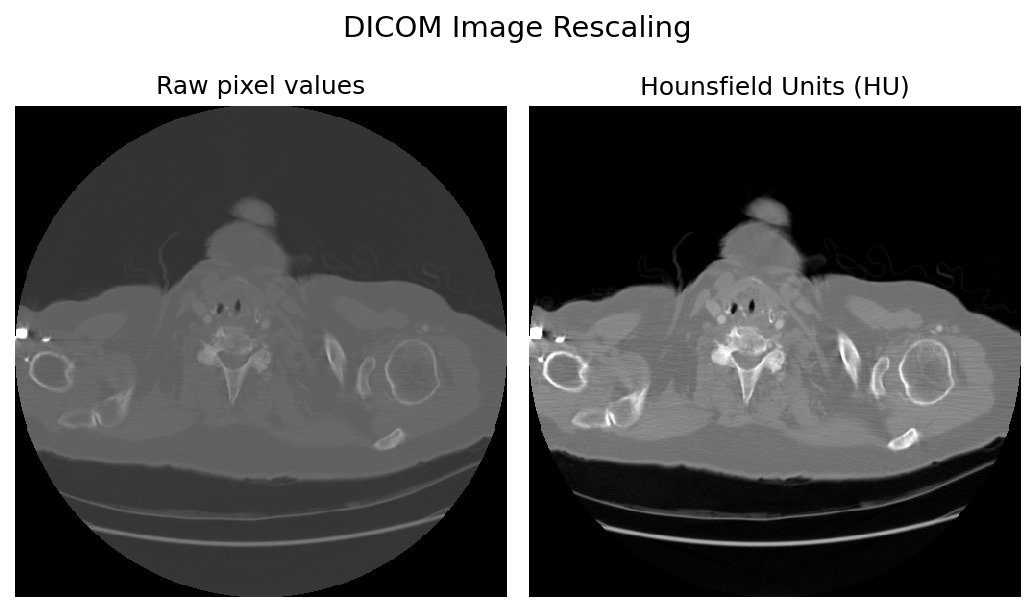

In [33]:
# handle missing pydicom
if not HAS_DICOM:
    print("Skipping — pydicom not installed.")

else:

    # Find first available DICOM file in raw directory
    dcm_files = sorted(RAW_DIR.glob("**/*.dcm"))
    
    if dcm_files:

        # load one example slice and extract raw pixel data
        dcm = pydicom.dcmread(dcm_files[0])
        raw_pixels = dcm.pixel_array.astype(np.float32)

        # calculate slope 
        slope = float(getattr(dcm, 'RescaleSlope', 1.0))

        # calculate intercept
        intercept = float(getattr(dcm, 'RescaleIntercept', 0.0))

        # apply rescaling to HU 
        hu_image  = raw_pixels * slope + intercept
        
        # print summary of ranges and shape
        print(f"Raw pixel range  : [{raw_pixels.min():.0f}, {raw_pixels.max():.0f}]")
        print(f"HU range         : [{hu_image.min():.0f}, {hu_image.max():.0f}] HU")
        print(f"Image shape      : {hu_image.shape}")
        
        # plot raw pixels and HU side by side
        fig, axes = plt.subplots(1, 2, figsize=(7, 4))
        axes[0].imshow(raw_pixels, cmap="gray")
        axes[0].set_title("Raw pixel values")
        axes[0].axis("off")
        
        # set min and max for HU display to typical range for soft tissues
        axes[1].imshow(hu_image, cmap="gray", vmin=-1000, vmax=1000)
        axes[1].set_title("Hounsfield Units (HU)")
        axes[1].axis("off")
        
        plt.suptitle("DICOM Image Rescaling", y=1.02, fontsize=14)
        plt.tight_layout()
        plt.savefig("../figures/03/01_dicom_raw.pdf", bbox_inches="tight")
        plt.show()

The raw pixel image appears relatively low in contrast because the stored pixel values do not directly represent physical tissue attenuation. After conversion to Hounsfield Units (HU), the distinction between different tissue types becomes much clearer, resulting in improved visual contrast throughout the image. Furthermore, HU values have a direct physical interpretation, with different tissues occupying characteristic HU ranges.

## 5. Hounsfield Units (HU): The CT Intensity Scale

CT scanners measure X-ray attenuation, expressed in Hounsfield Units (HU):

| Tissue          | Typical HU range |
|-----------------|-----------------|
| Air             | −1000           |
| Lung (inflated) | −700 to −600    |
| Fat             | −100 to −50     |
| Water           | 0               |
| Soft tissue     | +20 to +80      |
| Bone            | +400 to +1000   |

In clinical settings, Radiologists can adjust the minimum and maximum values of the display window in order to focus on specific tissues.

### From HU to linear attenuation µ

Hounsfield Units are convenient for clinical interpretation, but the CT forward model used by the reconstruction operator works on **linear attenuation coefficients** µ — the physical quantity that X-rays actually attenuate by. The relationship is linear:

$$\mu = \left(\frac{HU}{1000} + 1\right) \cdot \mu_{\text{water}}$$

The physical value of $\mu_{\text{water}}$ at ~70 keV is about 0.2 cm⁻¹, but **LION normalises so that $\mu_{\text{water}} = 1.0$** in its dataloader output. This gives images in the range [0, ~2.45] rather than [0, ~0.46], which is a more numerically convenient range for the policy network and the ADMM updates (see NB05 sensitivity analysis for the hyperparameter consequences). All downstream notebooks operate in this LION-native range.

We develop the conversion inline below to confirm it produces non-negative µ with water mapping to 1.0, then import the package version and verify they agree.

In [ ]:
# LION-native scaling (physical value at 70 keV is ~0.2 cm⁻¹)
MU_WATER = 1.0

# define function to convert Hounsfield to LION-native and clip at 0
def _from_HU_to_mu_inline(img_hu, mu_water=MU_WATER):
    """
    Convert Hounsfield Units to LION-native linear attenuation µ, clipped at 0.
    """
    return np.clip((img_hu / 1000.0 + 1.0) * mu_water, 0, None)

# grab one slice to verify on
_one_slice = next(PROCESSED_DIR.glob("**/slice_*.npy"))
raw_hu = np.load(_one_slice).astype(np.float32)
mu_img = _from_HU_to_mu_inline(raw_hu)

# print summary
print(f"HU range : [{raw_hu.min():.0f}, {raw_hu.max():.0f}]")
print(f"µ range  : [{mu_img.min():.4f}, {mu_img.max():.4f}] (LION-native)")
print(f"Water (HU=0)     maps to µ = {_from_HU_to_mu_inline(np.array(0.0)):.3f} — should be 1.0")
print(f"Air   (HU=-1000) maps to µ = {_from_HU_to_mu_inline(np.array(-1000.0)):.3f} — should be 0.0")

HU range : [-3024, 1455]
µ range  : [0.0000, 2.4550] (LION-native)
Water (HU=0)     maps to µ = 1.000 — should be 1.0
Air   (HU=-1000) maps to µ = 0.000 — should be 0.0


#### Import and Verify

In [ ]:
# import package 
from ct_tfpnp.datasets.lidc import from_HU_to_mu

# compare package and inline versions
mu_pkg = from_HU_to_mu(raw_hu)
assert np.allclose(mu_pkg, mu_img), "package and inline versions disagree"

# print summary
print(f"✓ ct_tfpnp.datasets.lidc.from_HU_to_mu matches inline version "
      f"(max diff = {np.abs(mu_pkg - mu_img).max():.2e})")

✓ ct_tfpnp.datasets.lidc.from_HU_to_mu matches inline version (max diff = 0.00e+00)


### Visualise Different HU windows

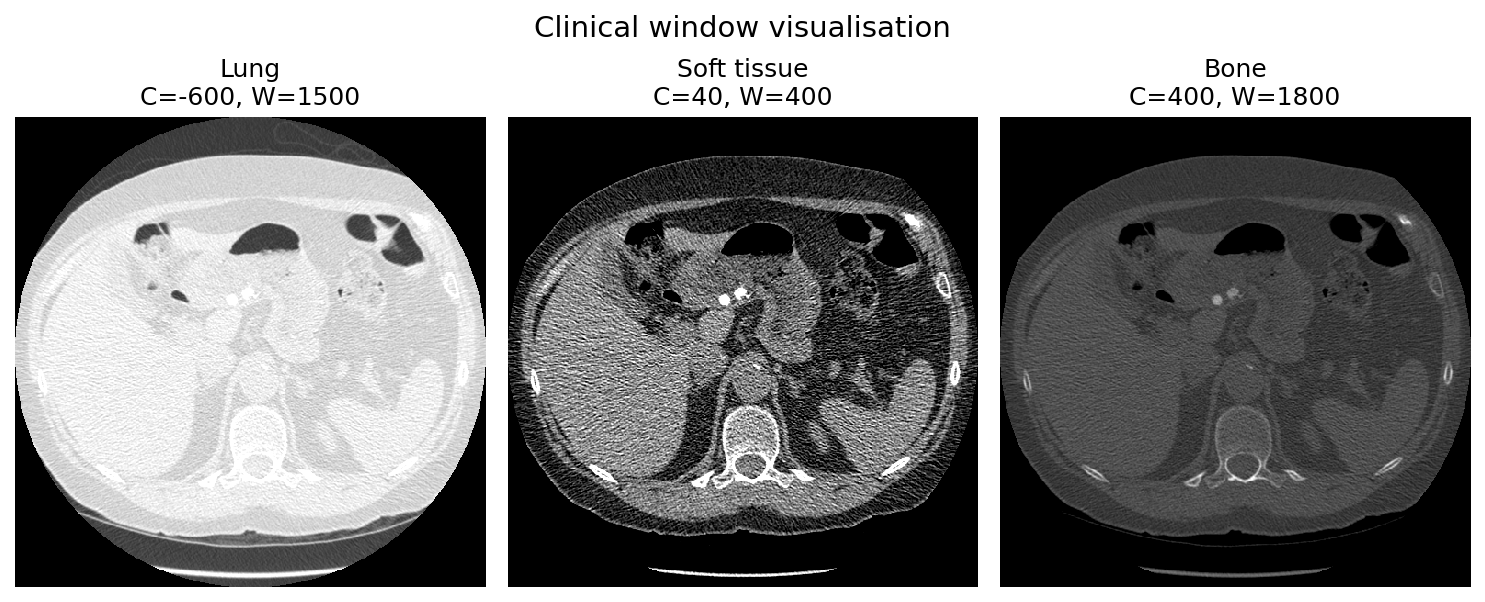

Best slice: 1-451.dcm


In [ ]:
# handle missing pydicom
if not HAS_DICOM:
    print("Skipping — pydicom not installed.")

else:

    # Find first available DICOM file in raw directory
    dcm_files = sorted(RAW_DIR.glob("**/*.dcm"))
    if dcm_files:
        
        # select 20 slices from interquartal range of scan
        candidate_slices = dcm_files[len(dcm_files)//4 : len(dcm_files)//4 + 20]
        
        # create variables to track best slice and std
        best_slice = None
        best_std = 0
        best_file = None

        # loop through slices
        for f in candidate_slices:

            # load DICOM
            d = pydicom.dcmread(f)

            # obtain raw pixel values (image)
            p = d.pixel_array.astype(np.float32)
            
            # rescale to HU
            p = p * float(getattr(d, 'RescaleSlope', 1)) + float(getattr(d, 'RescaleIntercept', 0))

            # select slice with highest standard deviation
            if p.std() > best_std:
                best_std = p.std()
                best_slice = p
                best_file = f
        
        # define function to apply windowing for given centre and width
        def apply_window(img_hu, centre, width):
            lo = centre - width / 2
            hi = centre + width / 2
            return np.clip((img_hu - lo) / (hi - lo), 0, 1)
        
        # define common windows for different tissues
        windows = [
            ("Lung",        -600, 1500),
            ("Soft tissue",   40,  400),
            ("Bone",         400, 1800),
        ]
        
        # plot slice with different window settings
        fig, axes = plt.subplots(1, 3, figsize=(10, 4))

        for ax, (name, ctr, wid) in zip(axes, windows):

            # apply windowing
            windowed = apply_window(best_slice, ctr, wid)

            # display windowed image
            ax.imshow(windowed, cmap="gray", vmin=0, vmax=1)
            ax.set_title(f"{name}\nC={ctr}, W={wid}")
            ax.axis("off")
        
        # show and save figure
        plt.suptitle("Clinical window visualisation", y=1.02, fontsize=14)
        plt.tight_layout()
        plt.savefig("../figures/03/02_hu_windows.pdf", bbox_inches="tight")
        plt.show()

        print(f"Best slice: {Path(best_file).name}")

The effects of different CT window settings can clearly be seen across the figure, despite everything being generated from the same Hounsfield Unit image. The lung window highlights pulmonary parenchyma and airway detail, the soft tissue window improves visualisation of mediastinal and vascular structures, and the bone window enhances high-density anatomy while suppressing soft tissue contrast. This illustrates how clinically meaningful HU values allow image contrast to be tailored to specific diagnostic tasks through windowing, something that would not be possible with raw pixels.

## 6. LION's Preprocessing Pipeline

LION's `pre_process_lidc_idri.py` converts raw DICOM files into `.npy` files using `pylidc` to handle DICOM parsing and annotation extraction.

the `.npy` files store raw `int16` Hounsfield Unit values (range approximately −2048 to +1400) and are not pre-normalised to [0, 1], as this happens inside `LIDC_IDRI.__getitem__()` at load time via `ct.from_HU_to_mu()` (reconstruction) or `ct.from_HU_to_normal()` (segmentation).

The processed directory also contains `mask_*.npy` files which are binary nodule annotation masks, not CT images, and must be excluded when loading slices which is done by using `glob("**/slice_*.npy")`.

File         : LIDC-IDRI-0001/slice_0.npy
dtype        : int16
Value range  : [-2048, 1416] HU
Total slices : 242704 across 1009 patients


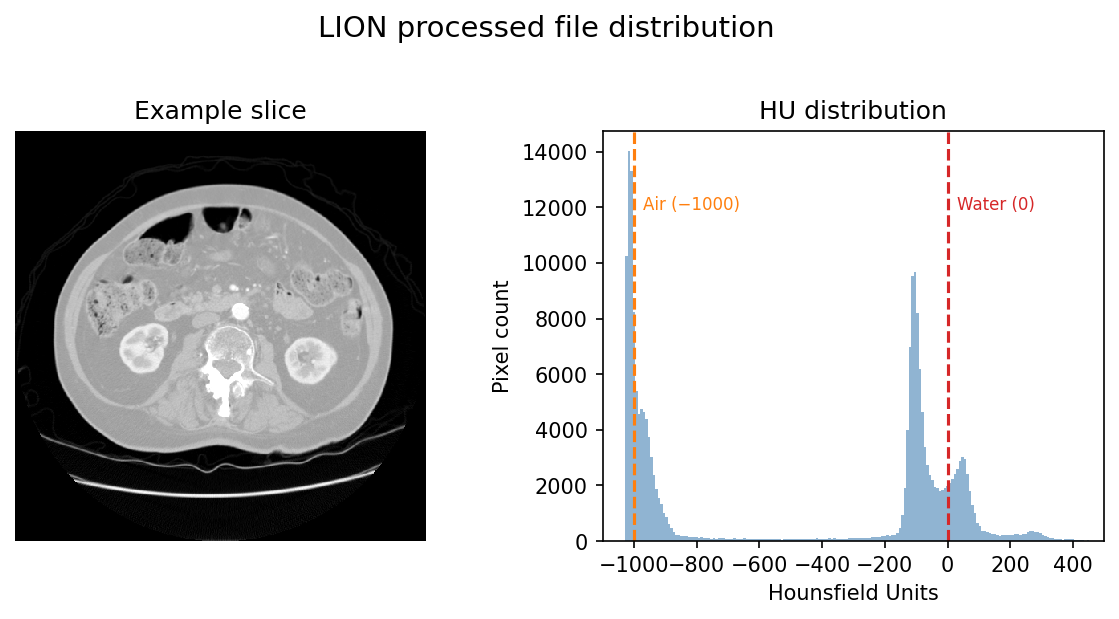

In [ ]:
# load processed .npy files and patient count
npy_files = sorted(PROCESSED_DIR.glob("**/slice_*.npy"))
patients  = sorted(set(f.parent.name for f in npy_files))

# add error handling for missing .npy files
if not npy_files:
    print("No slice_*.npy files found. Check your processed data path.")

else:

    # load one example slice to check data type and value range
    raw = np.load(npy_files[0])
    print(f"File       : {npy_files[0].parent.name}/{npy_files[0].name}")
    print(f"dtype      : {raw.dtype}")
    print(f"Value range: [{raw.min()}, {raw.max()}] HU")

    # print summary of dataset size
    print(f"Total slices: {len(npy_files)} across {len(patients)} patients")

    # plot example slice with lung window and histogram of HU values
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(apply_lung_window(raw), cmap="gray", vmin=0, vmax=1)
    axes[0].set_title("Example slice")
    axes[0].axis("off")

    pixels = raw.astype(np.float32).ravel()

    # Clip display range to remove empty space
    axes[1].hist(pixels, bins=200, color="C0", edgecolor="none", alpha=0.6, range=(-1100, 500))

    # Annotate lines
    axes[1].axvline(-1000, color="C1",    ls="--", lw=1.5)
    axes[1].axvline(    0, color="C3",  ls="--", lw=1.5)
    ymax = axes[1].get_ylim()[1]
    axes[1].text(-970, ymax * 0.8, "Air (−1000)",  color="C1", ha="left", va="bottom", fontsize=8)
    axes[1].text(  30, ymax * 0.8, "Water (0)",    color="C3", ha="left", va="bottom", fontsize=8)

    # add labels and titles
    axes[1].set_xlabel("Hounsfield Units")
    axes[1].set_ylabel("Pixel count")
    axes[1].set_title("HU distribution")
    axes[1].set_xlim(-1100, 500)

    # show and save figure
    plt.suptitle("LION processed file distribution", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.savefig("../figures/03/03_preprocessing_pipeline.pdf", bbox_inches="tight")
    plt.show()

We can see both from the printed output and the histogram that the processed files store Hounsfield Unit values rather than normalised pixel values. The printed
output confirms the `int16` dtype and the value range (approximately −2048 to +1400), and the histogram confirms this further by showing the characteristic bimodal distribution expected from a CT scan, with a sharp peak at −1000 HU corresponding to air (background outside the patient and inside the lungs), and a broader peak centred near −200 to 200 HU corresponding to soft tissue, fat, and organs. If the files had been normalised to [0,1], the same distribution would appear compressed into the [0, 1] range on the x-axis.

This confirms that `ct.from_HU_to_mu()` must be applied at load time before passing images to the CT operator, and this is exactly what LION's `LIDC_IDRI.__getitem__()` does automatically when set to `task="reconstruction"`.

### Detecting slices that contain lungs

Lung slices have a large fraction of dark pixels in the central region of the image, making it easy to define a function to filter them out from other slices.

We develop the detector inline, verify it labels obvious lung and non-lung slices correctly, and import the package version for verification.

In [ ]:
def _is_lung_slice_inline(img, dark_threshold=None, min_dark_fraction=0.15):
    """
    Returns True if the slice likely contains lungs.
    """
    # convert to numpy if input is a torch tensor
    if isinstance(img, torch.Tensor):
        img = img.squeeze().cpu().numpy()

    # convert to array and squeeze to 2D
    img = np.asarray(img).squeeze()

    # set default dark threshold to 20%
    if dark_threshold is None:
        dark_threshold = img.max() * 0.2

    # define image dimensions and central region
    h, w = img.shape
    centre = img[h // 4 : 3 * h // 4, w // 5 : 4 * w // 5]

    # compute fraction of pixels below dark threshold and compare to minimum
    return float((centre < dark_threshold).mean()) > min_dark_fraction

# sort files for first patient and load top and middle slices
pat0_files = sorted(f for f in npy_files if f.parent.name == patients[0])
top_slice    = np.load(pat0_files[0]).astype(np.float32)
middle_slice = np.load(pat0_files[len(pat0_files)//2]).astype(np.float32)

# print function output
print(f"Top slice    is_lung_slice = {_is_lung_slice_inline(top_slice, dark_threshold=-500)}")
print(f"Middle slice is_lung_slice = {_is_lung_slice_inline(middle_slice, dark_threshold=-500)}")

Top slice    is_lung_slice = False
Middle slice is_lung_slice = False


#### Import and Verify

In [ ]:
# import from package
from ct_tfpnp.datasets.lidc import is_lung_slice

# convert to µ images
mu_top    = from_HU_to_mu(top_slice)
mu_middle = from_HU_to_mu(middle_slice)

# verify package matches inline
print(f"On µ images (package auto-threshold):")
print(f"Top slice    is_lung_slice = {is_lung_slice(mu_top)}")
print(f"Middle slice is_lung_slice = {is_lung_slice(mu_middle)}")
print("✓ package is_lung_slice available; gallery cell below uses lung_score for ranking (returns a float), but filtering elsewhere uses this version.")

On µ images (package auto-threshold):
  Top slice    is_lung_slice = False
  Middle slice is_lung_slice = False
✓ package is_lung_slice available; gallery cell below uses lung_score for ranking (returns a float), but filtering elsewhere uses this version.


## 7. Slice Gallery: Real Lung CT

The model trains on the processed data, so to understand what it is seeing, we visualise a sample of slices by creating a slice gallery.

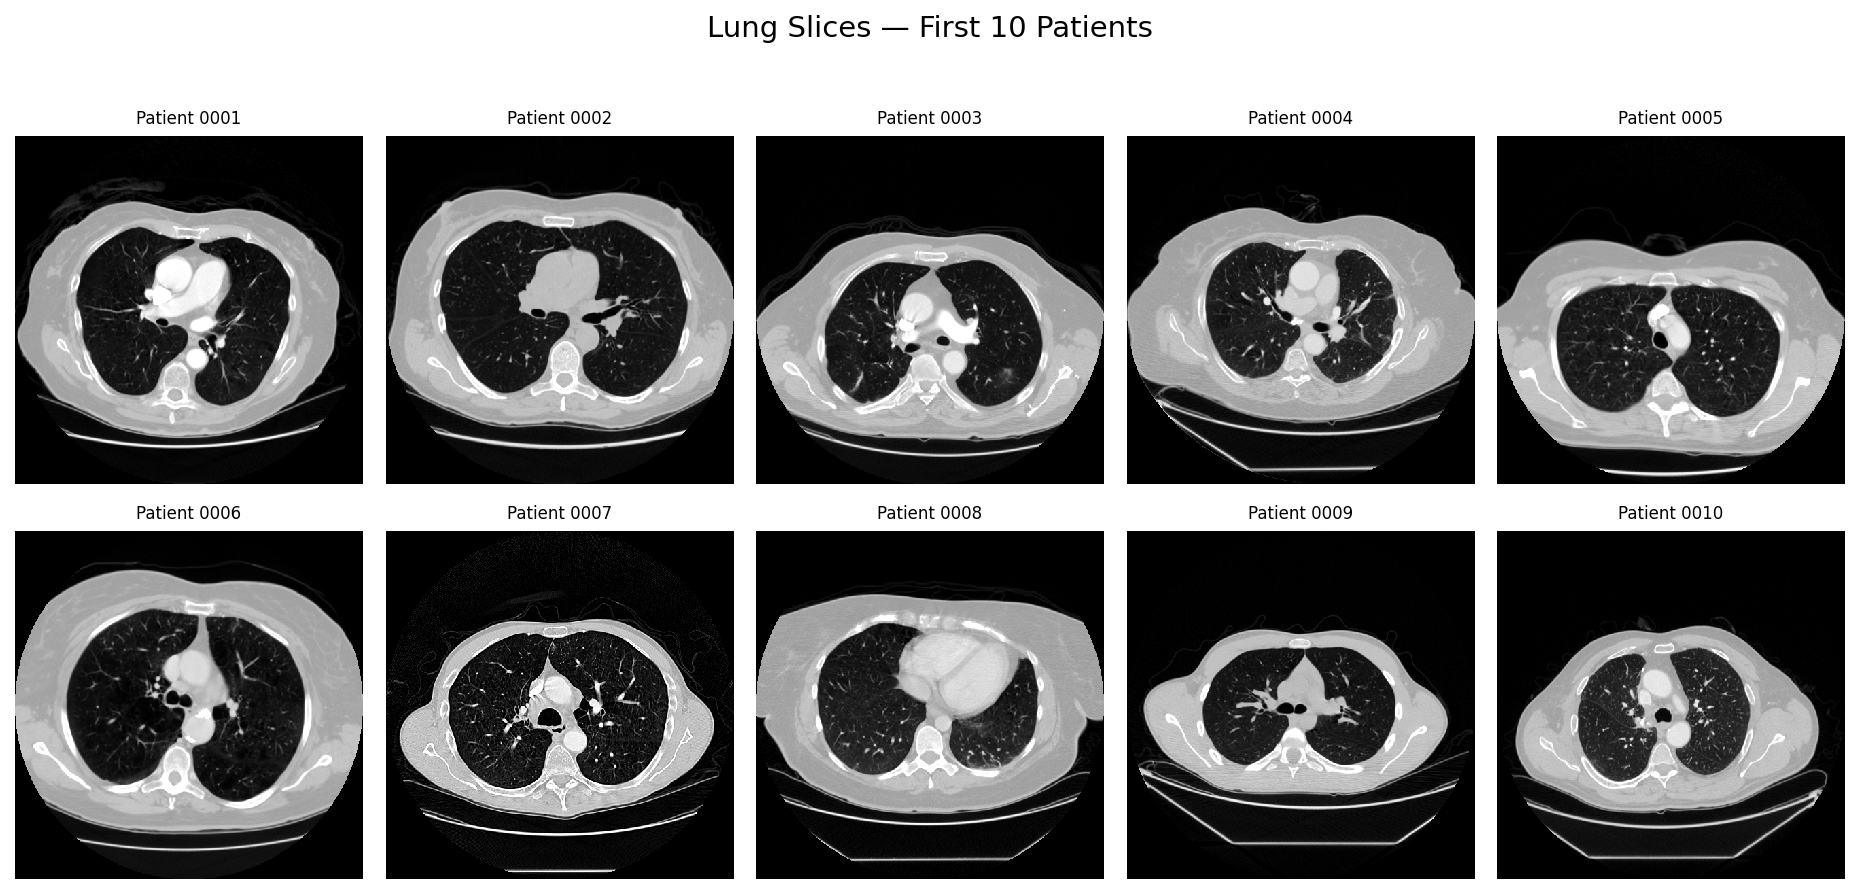

In [ ]:
if npy_files:
    # restrict to first 10 patients to keep the gallery to one figure
    gallery_patients = patients[:10]

    def lung_score(fpath, dark_threshold=-500):
        """
        Returns a score indicating likelihood of slice containing lung fields by checking for dark pixels in central 50% of image.
        """
        img = np.load(fpath).astype(np.float32)
        h, w = img.shape

        # define the centre by setting margins to 25% of height and 20% of width
        centre = img[h//4 : 3*h//4, w//5 : 4*w//5]
        return (centre < dark_threshold).mean()

    # Pick best lung slice per patient
    gallery_files = []
    for pat in gallery_patients:

        # sort files
        pat_files = sorted(f for f in npy_files if f.parent.name == pat)

        # manually handle 0009 as pipeline was failing
        if pat == "LIDC-IDRI-0009":
            gallery_files.append(pat_files[int(len(pat_files) * 0.2)])
            continue

        # filter to find lung slice with highest score
        lung_files = [f for f in pat_files if lung_score(f) > 0.15]
        if lung_files:
            gallery_files.append(max(lung_files, key=lung_score))
        else:
            gallery_files.append(max(pat_files, key=lambda f: np.load(f).std()))

    # define size of figure
    n = len(gallery_files)
    ncols = min(5, n)
    nrows = (n + ncols - 1) // ncols

    # plot slice gallery
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 3))
    axes = np.array(axes).reshape(-1) if n > 1 else [axes]
    for ax, fpath in zip(axes, gallery_files):
        img = np.load(fpath).astype(np.float32)
        ax.imshow(apply_lung_window(img), cmap="gray", vmin=0, vmax=1)
        ax.set_title(fpath.parent.name.replace("LIDC-IDRI-", "Patient "), fontsize=8)
        ax.axis("off")
    for ax in axes[len(gallery_files):]:
        ax.set_visible(False)

    # show and save figure
    plt.suptitle("Lung Slices — First 10 Patients", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.savefig("../figures/03/04_slice_gallery.pdf", bbox_inches="tight")
    plt.show()

The figure above shows one representative lung slice from each patient in the subset dataset. Slices were selected automatically by identifying images containing a sufficiently large proportion of lung-like pixels (HU < -500) within the central region of the scan, ensuring that the chosen slice contained visible pulmonary anatomy rather than the neck or upper abdomen. The only anomaly was patient 0009, whose slice had to be selected manually due to the different ordering of the slices in the patient folder. All images are displayed using a lung window (-1000 to +400 HU), highlighting the lung parenchyma and demonstrating the anatomical diversity present across the cohort.

## 8. Axial Slice Progression

To understand why a patient-level train/test split is necessary, it is useful to visualise how slices from the same patient vary across the volume. If slices were split at the individual level rather than the patient level, near-identical slices from the same patient could appear in both the training and test sets, causing the model to appear to generalise when it is simply memorising patient-specific anatomy.

The plot below samples 15 evenly-spaced slices from a single patient, showing the full extent of the scan from the upper chest down through the abdomen.

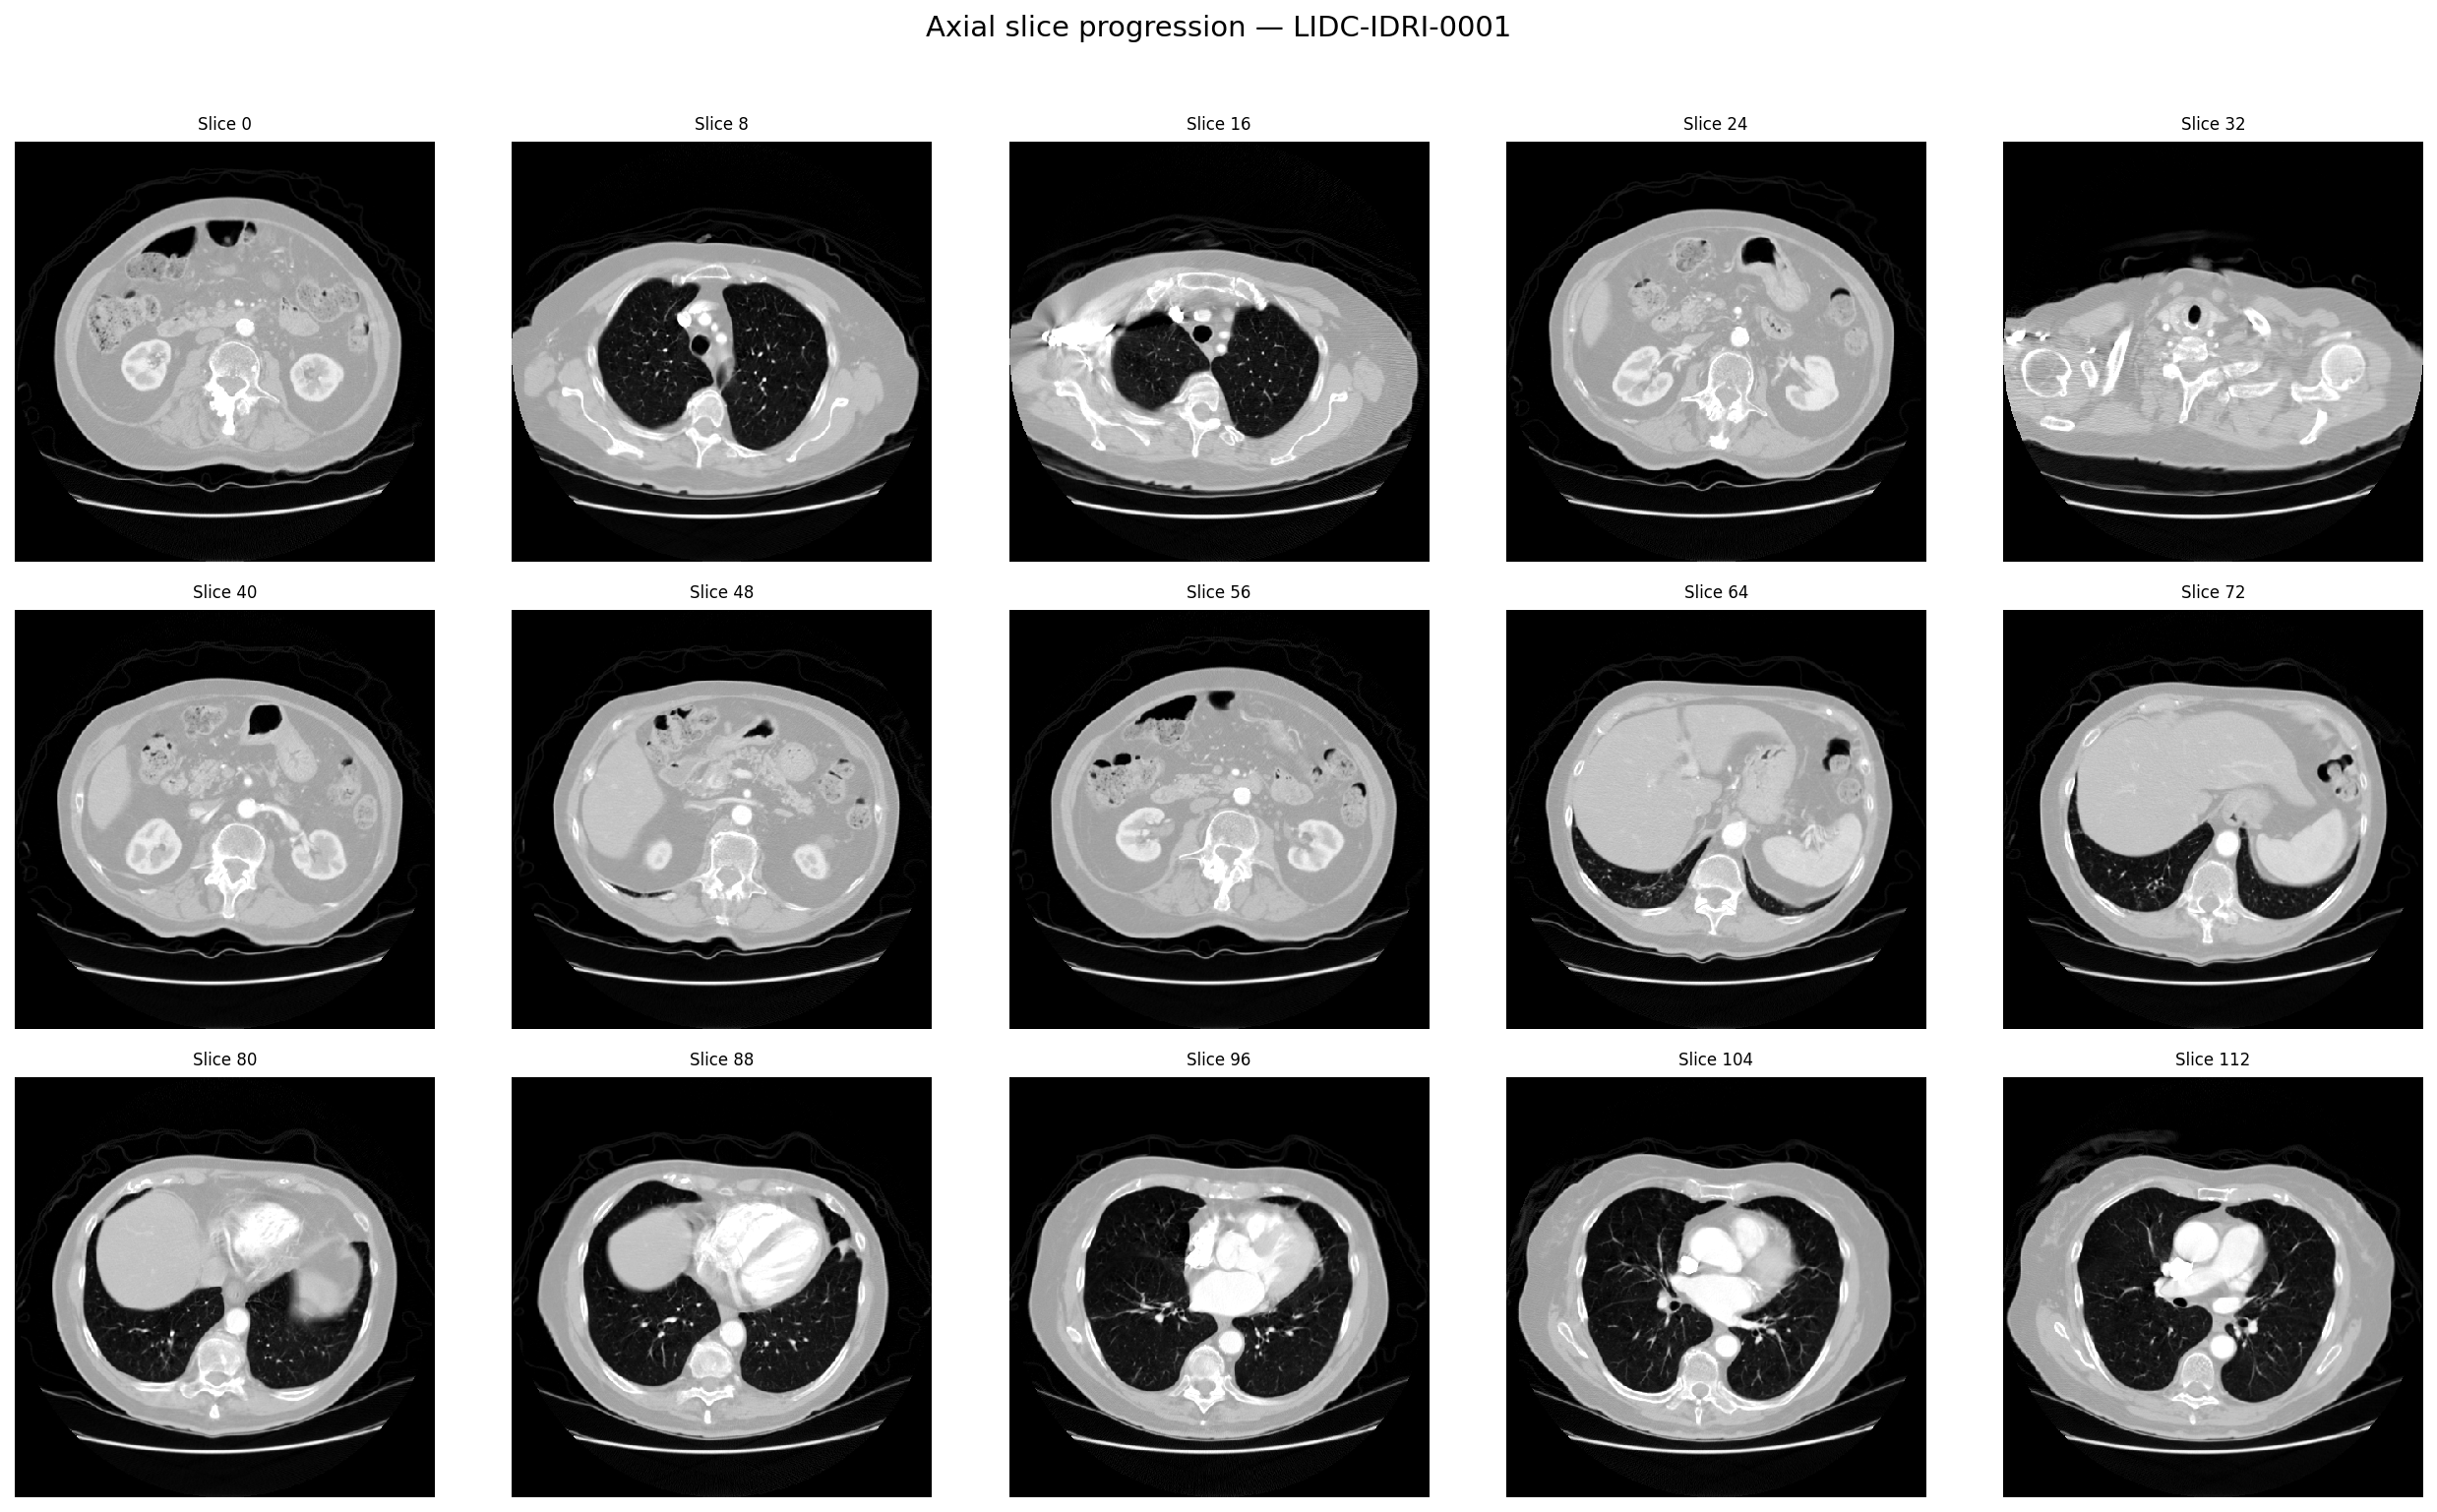

In [42]:
if npy_files:

    # sample 15 slices evenly spaced through the volume
    step = max(1, len(patient_files) // 15)
    sample_indices = list(range(0, len(patient_files), step))[:15]

    # plot gallery of sampled slices with lung windowing
    fig, axes = plt.subplots(3, 5, figsize=(17, 10))
    axes = axes.ravel()

    for ax, idx in zip(axes, sample_indices):
        img = np.load(patient_files[idx]).astype(np.float32)
        ax.imshow(apply_lung_window(img), cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"Slice {idx}", fontsize=8)
        ax.axis("off")

    # show and save figure
    plt.suptitle(f"Axial slice progression — {first_patient}", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.savefig("../figures/03/06_slice_progression.pdf", bbox_inches="tight")
    plt.show()

The progression shows that adjacent slices are highly similar, differing only by a few millimetres of anatomy. This is why LION splits the dataset at the patient level rather than the slice level, because if slices from the same patient appeared in both training and test sets, the model could trivially generalise by memorising patient-specific anatomy rather than learning a general reconstruction strategy, artificially inflating evaluation metrics.

## 9. Intensity Distribution Analysis

Understanding the intensity distribution of the dataset is important for:

- Understanding which slices contain useful anatomical content and which are mostly air, as low-std slices provide little training signal
- Checking data quality to prevent unexpected distributions from flagging preprocessing errors
- Understanding the range of values the denoiser and CT operator will receive after `ct.from_HU_to_mu()` is applied at load time

Statistics over 101 sampled slices:
  Mean of means : -786.4 HU
  Mean of stds  : 923.0 HU
  Min observed  : -32767 HU
  Max observed  : 32767 HU


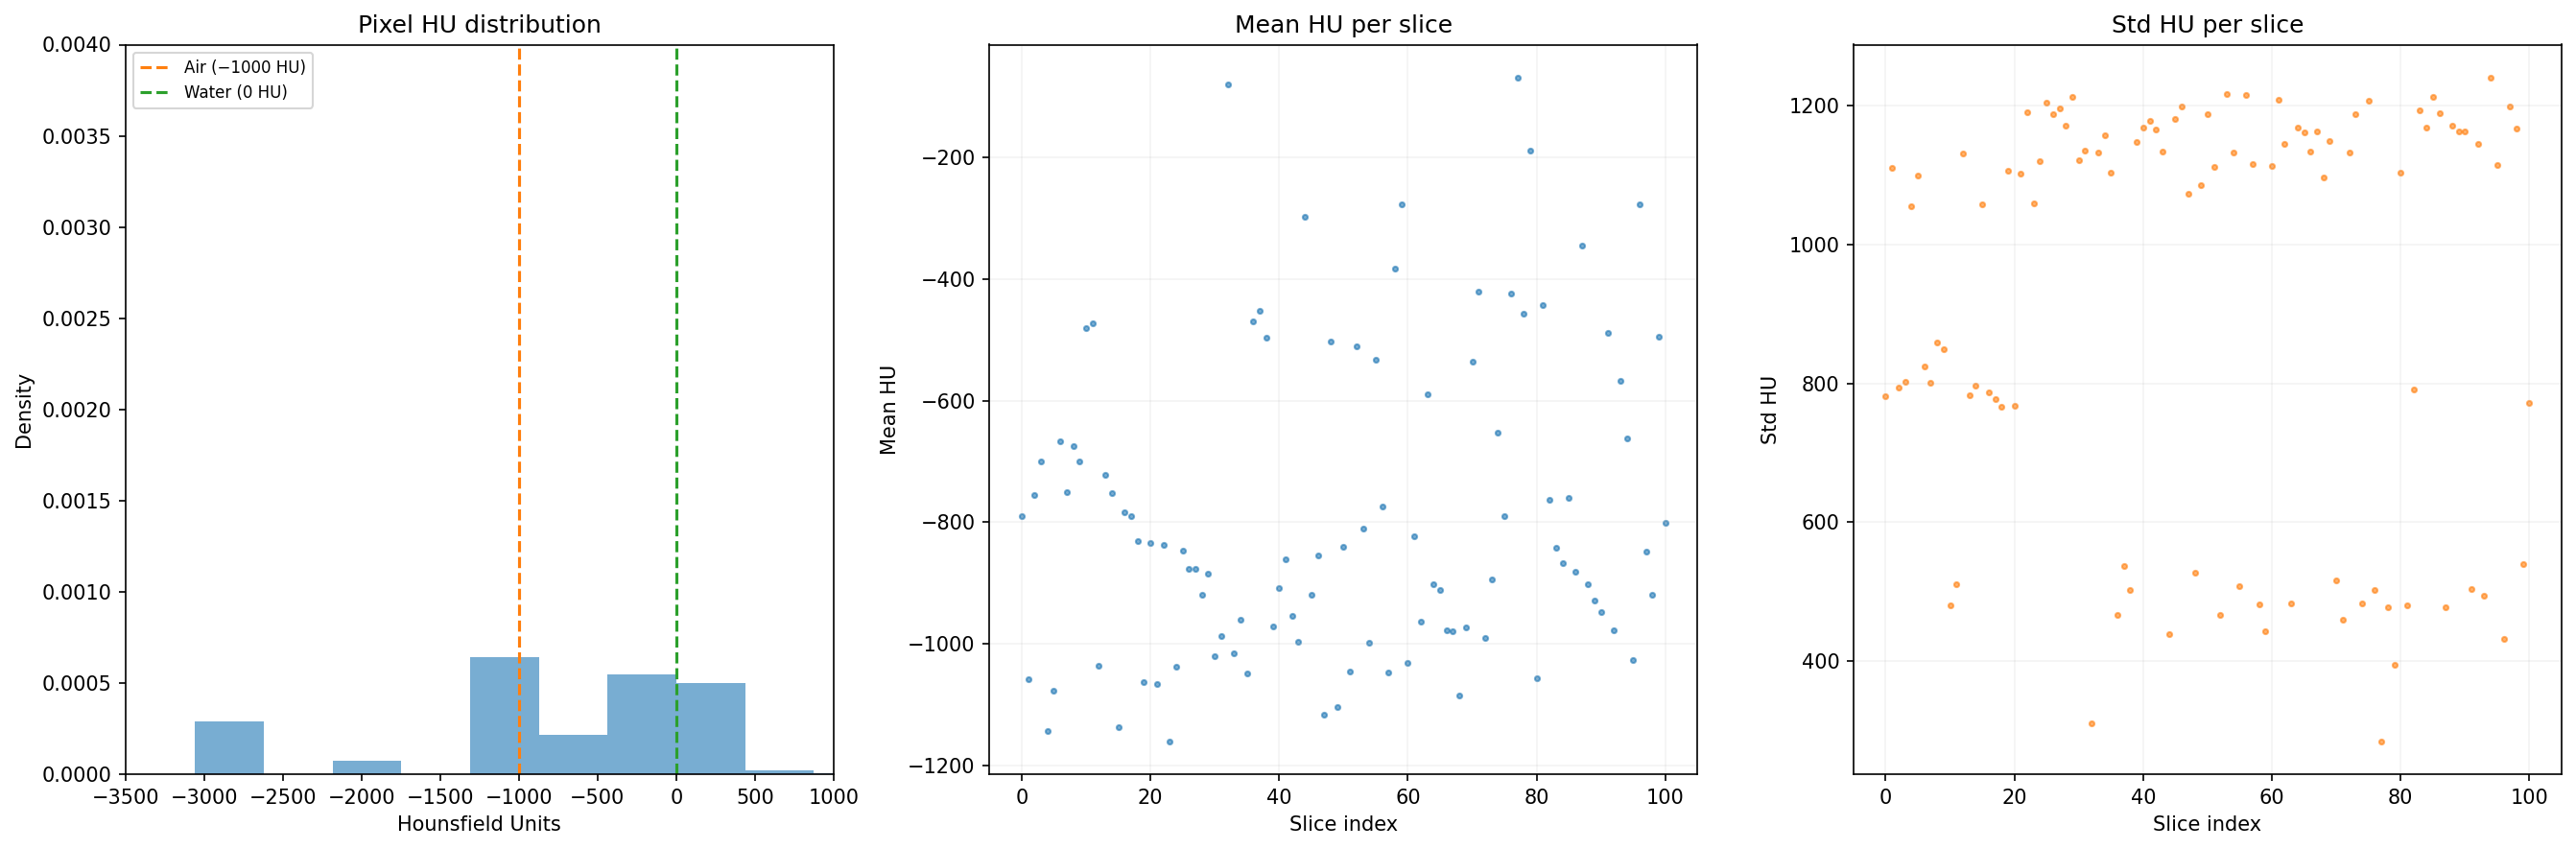

In [43]:
if npy_files:

    # Sample up to 100 slices for speed
    sample_files = npy_files[::max(1, len(npy_files)//100)]
    all_means, all_stds, all_mins, all_maxs = [], [], [], []

    # Loop through sampled files and compute statistics
    for f in sample_files:
        img = np.load(f).astype(np.float32)
        all_means.append(img.mean())
        all_stds.append(img.std())
        all_mins.append(img.min())
        all_maxs.append(img.max())

    print(f"Statistics over {len(sample_files)} sampled slices:")
    print(f"  Mean of means : {np.mean(all_means):.1f} HU")
    print(f"  Mean of stds  : {np.mean(all_stds):.1f} HU")
    print(f"  Min observed  : {min(all_mins):.0f} HU")
    print(f"  Max observed  : {max(all_maxs):.0f} HU")

    # plot histograms and scatter plots of statistics
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    all_pixels = np.concatenate([np.load(f).astype(np.float32).ravel() for f in sample_files])

    axes[0].hist(all_pixels, bins=150, color="C0", alpha=0.6, edgecolor="none", density=True)
    axes[0].axvline(-1000, color="C1", ls="--", lw=1.5, label="Air (−1000 HU)")
    axes[0].axvline(    0, color="C2", ls="--", lw=1.5, label="Water (0 HU)")

    # clipped display range to eliminate empty space
    axes[0].set_xlim(-3500, 1000)
    axes[0].set_ylim(0, 0.004)

    axes[0].set_xlabel("Hounsfield Units")
    axes[0].set_ylabel("Density")
    axes[0].set_title("Pixel HU distribution")
    axes[0].legend(fontsize=8)

    axes[1].scatter(range(len(all_means)), all_means, s=6, alpha=0.6, c="C0")
    axes[1].grid(True, alpha=0.15)
    axes[1].set_xlabel("Slice index")
    axes[1].set_ylabel("Mean HU")
    axes[1].set_title("Mean HU per slice")

    axes[2].scatter(range(len(all_stds)), all_stds, s=6, alpha=0.6, c="C1")
    axes[2].grid(True, alpha=0.15)
    axes[2].set_xlabel("Slice index")
    axes[2].set_ylabel("Std HU")
    axes[2].set_title("Std HU per slice")

    # show and save figure
    plt.tight_layout()
    plt.savefig("../figures/03/07_intensity_distribution.pdf", bbox_inches="tight")
    plt.show()

## 10. Train / Validation / Test Split

LION splits the dataset at the **patient level** (not slice level) to prevent data leakage and ensure that slices from the same patient never appear in both training and test sets, as adjacent slices are too similar.

The standard LION split on the full 1018-patient dataset is approximately:

- Training (80%): used to fit the policy and critic networks
- Validation (10%): used for hyperparameter tuning and checkpoint selection
- Test (10%): held out for final evaluation in NB10

Rather than re-implementing the split here, we delegate to LION's built-in `LIDC_IDRI` dataloader via the `get_lion_split` helper in `ct_tfpnp.datasets.lidc`. This guarantees that every notebook in the project sees the same patient assignment.

### Loading LION's split through a thin wrapper

The patient-level split is delegated to LION's `LIDC_IDRI` dataloader. Rather than instantiating it directly throughout the project, we wrap it in a small helper, `get_lion_split`, which returns a list of `(1, H, W)` float tensors on the chosen device. This is the function every downstream notebook calls.

We sketch it inline so its behaviour is transparent, then import the package version and confirm we get the same counts and tensor properties.

Note: LION's LIDC_IDRI constructor expects a geometry object even when we only need the ground-truth images. We import the canonical one from ct_tfpnp.experiments.parallel_beam_ct and treat it as configuration here — the geometry itself, including projection angles, detector spacing, and sparse-view conventions, is developed in NB05.

In [ ]:
import torch
from LION.data_loaders.LIDC_IDRI import LIDC_IDRI
from ct_tfpnp.experiments.parallel_beam_ct import ParallelBeamSparseViewCT

# LION's dataloader requires a geometry to instantiate, which is developed and explored in NB05, but imported here for convenience.
geometry = ParallelBeamSparseViewCT().experiment_params.geometry

def _get_lion_split_inline(split="train", geometry=None, device="cpu"):

    # set dataset path
    ds = LIDC_IDRI(mode=split, geometry_parameters=geometry)
    imgs = []

    # collect images, ensuring they are 3D
    for i in range(len(ds)):
        _, gt = ds[i]
        if gt.dim() == 2:
            gt = gt.unsqueeze(0)
        imgs.append(gt.float().to(device))

    return imgs

# load validation split using inline function
val_inline = _get_lion_split_inline("validation", geometry=geometry, device="cpu")

# print summary of split
print(f"Inline validation split : {len(val_inline)} images, "
      f"shape {tuple(val_inline[0].shape)}, "
      f"range [{val_inline[0].min():.3f}, {val_inline[0].max():.3f}]")

Preparing patient list, this may take time....
Patient lists ready for validation dataset
Inline validation split : 401 images, shape (1, 512, 512), range [0.000, 2.396]


#### Import and Verify

In [ ]:
# load package version
from ct_tfpnp.datasets.lidc import get_lion_split

# confirm package version matches
val_pkg, _ = get_lion_split(split="validation", geometry=geometry, device="cpu")
assert len(val_pkg) == len(val_inline), "count mismatch"
assert val_pkg[0].shape == val_inline[0].shape, "shape mismatch"
assert torch.allclose(val_pkg[0], val_inline[0]), "tensor values differ"
print(f"✓ ct_tfpnp.datasets.lidc.get_lion_split matches inline version")

# oad all three splits
print("\nLION patient-level splits (full LIDC-IDRI):")
for split in ("train", "validation", "test"):
    imgs, _ = get_lion_split(split=split, geometry=geometry, device="cpu")
    print(f"  {split:<10s}: {len(imgs):>5d} slices  "
          f"range [{imgs[0].min():.4f}, {imgs[0].max():.4f}]")

Preparing patient list, this may take time....
Patient lists ready for validation dataset
LION validation split: 401 images, range [0.0000, 2.3958]
✓ ct_tfpnp.datasets.lidc.get_lion_split matches inline version

LION patient-level splits (full LIDC-IDRI):
Preparing patient list, this may take time....
Patient lists ready for train dataset
LION train split: 3300 images, range [0.0000, 2.4475]
  train     :  3300 slices  range [0.0000, 2.4475]
Preparing patient list, this may take time....
Patient lists ready for validation dataset
LION validation split: 401 images, range [0.0000, 2.3958]
  validation:   401 slices  range [0.0000, 2.3958]
Preparing patient list, this may take time....
Patient lists ready for test dataset
LION test split: 389 images, range [0.0000, 2.2075]
  test      :   389 slices  range [0.0000, 2.2075]


## 11. Summary

This notebook explored the structure and characteristics of the LIDC-IDRI CT dataset as used in the project. The raw DICOM format and `pylidc`-based preprocessing pipeline were examined to show how scanner-dependent integers are rescaled to Hounsfield Units and stored as int16 `.npy` files. Representative slices and three orthogonal volume views were visualised to give intuition for the anatomical content, and intensity statistics confirmed the expected bimodal HU distribution dominated by air and soft tissue.

The dataset was then loaded through LION's `LIDC_IDRI` dataloader via the `get_lion_split` helper, confirming the 3300 / 401 / 389 patient-level train/validation/test split that all downstream notebooks (NB05–NB10) rely on, and showing a real µ-valued training tensor in LION's native range.